In [4]:
import pandas as pd
file_path = '../data/data.csv'
df = pd.read_csv(file_path, sep=';')
display(df.head())
print(f"Dataset Shape: {df.shape}")

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Dataset Shape: (4424, 37)


In [7]:
print("1. Data Information (X-Ray of Dataset)")
df.info()

print("\n" + "="*50 + "\n")

print("2. Missing Values in Each Column")
missing_values = df.isnull().sum()

missing_columns = missing_values[missing_values > 0]

if missing_columns.empty:
    print("There are ZERO missing values in this dataset.")
else:
    print(missing_columns)

1. Data Information (X-Ray of Dataset)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Fa

In [6]:

missing_values = df.isnull().sum()

missing_columns = missing_values[missing_values > 0]

if missing_columns.empty:
    print("There are ZERO missing values in this dataset.")
else:
    print(missing_columns)

There are ZERO missing values in this dataset.


Missing Values in Dataset
0

 Duplicate Rows
Total duplicate rows found: 0


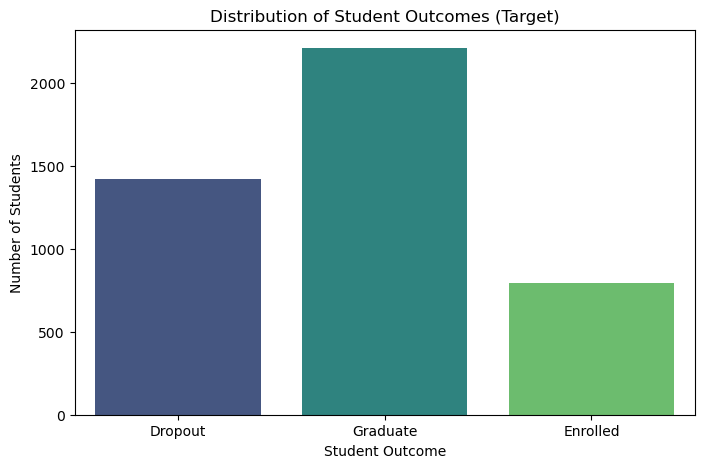

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Missing Values in Dataset")
print(df.isnull().sum().sum())

print("\n Duplicate Rows")
duplicates = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Target', hue='Target', palette='viridis', legend=False)
plt.title("Distribution of Student Outcomes (Target)")
plt.xlabel("Student Outcome")
plt.ylabel("Number of Students")
plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder

print("1. Target Column BEFORE Encoding")
target_counts = df['Target'].value_counts()
print(target_counts)
print("\n" + "="*50 + "\n")

encoder = LabelEncoder()

df['Target'] = encoder.fit_transform(df['Target'])

print("2. Target Column AFTER Encoding")
encoded_counts = df['Target'].value_counts()
print(encoded_counts)
print("\n" + "="*50 + "\n")

print("3. Encoding Mapping")
for i, class_name in enumerate(encoder.classes_):
    print(f"Number {i} represents: {class_name}")

1. Target Column BEFORE Encoding
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


2. Target Column AFTER Encoding
Target
2    2209
0    1421
1     794
Name: count, dtype: int64


3. Encoding Mapping
Number 0 represents: Dropout
Number 1 represents: Enrolled
Number 2 represents: Graduate


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Target', axis=1)
y = df['Target']

#Split into Training Data (80%) and Testing Data (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data Splitting Results")
print(f"Total dataset size: {df.shape}")
print(f"Training data (X_train) size: {X_train.shape} --> 80% of data for the model to learn from")
print(f"Testing data (X_test) size: {X_test.shape} --> 20% of data hidden for the final exam")

--- Data Splitting Results ---
Total dataset size: (4424, 37)
Training data (X_train) size: (3539, 36) --> 80% of data for the model to learn from
Testing data (X_test) size: (885, 36) --> 20% of data hidden for the final exam


In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

dt_base = DecisionTreeClassifier(random_state=42)

print("Running Grid Search... This will test hundreds of combinations!")
grid_search = GridSearchCV(estimator=dt_base, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)

print("\nBest Settings Found")
print(grid_search.best_params_)

best_tree_model = grid_search.best_estimator_
y_pred_optimized = best_tree_model.predict(X_test)

new_accuracy = accuracy_score(y_test, y_pred_optimized)
print(f"\n Old Accuracy was around: 67.68%")
print(f"New Optimized Accuracy: {new_accuracy * 100:.2f}%")

Running Grid Search... This will test hundreds of combinations!

Best Settings Found
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}

 Old Accuracy was around: 67.68%
New Optimized Accuracy: 73.56%


1. Model Accuracy
Overall Accuracy: 73.56%

2. Detailed Classification Report
              precision    recall  f1-score   support

     Dropout       0.88      0.65      0.75       316
    Enrolled       0.46      0.31      0.37       151
    Graduate       0.72      0.95      0.82       418

    accuracy                           0.74       885
   macro avg       0.69      0.64      0.65       885
weighted avg       0.74      0.74      0.72       885

3. Confusion Matrix Visualized


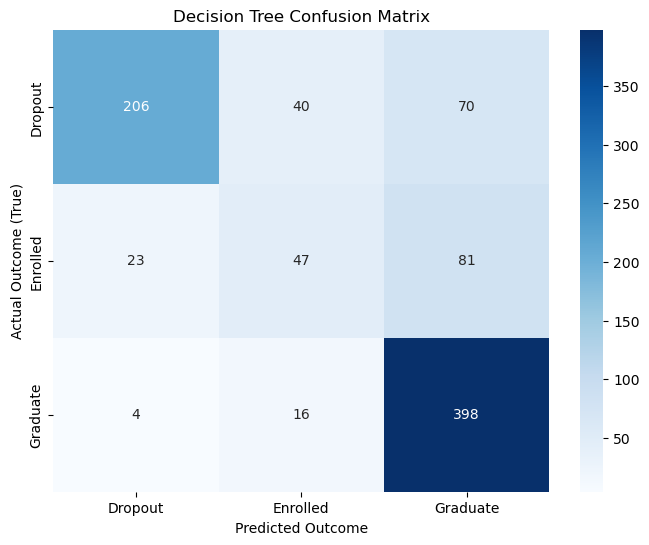

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred_optimized)
print("1. Model Accuracy")

print("Overall Accuracy: {:.2f}%\n".format(accuracy * 100))

print("2. Detailed Classification Report")
print(classification_report(y_test, y_pred_optimized, target_names=['Dropout', 'Enrolled', 'Graduate']))

print("3. Confusion Matrix Visualized")
cm = confusion_matrix(y_test, y_pred_optimized)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dropout', 'Enrolled', 'Graduate'],
            yticklabels=['Dropout', 'Enrolled', 'Graduate'])

plt.title('Decision Tree Confusion Matrix')
plt.ylabel('Actual Outcome (True)')
plt.xlabel('Predicted Outcome')

plt.show()
